In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random

torch.manual_seed(0)
np.random.seed(0)

In [3]:
T = 25
beta_0 = 0
delta = 0.01

beta = [beta_0 + delta * t for t in range(T+1)]
beta = torch.tensor(beta)

alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha,0)

print(f"beta_T = {beta[T]:.4f}")
print(f"alpha_bar_T = {alpha_bar[T]:.4f}")
print(f"signal scale at T:  sqrt(alpha_bar_T) = {torch.sqrt(alpha_bar[T]):.4f}")
print(f"noise std at T:     sqrt(1 - alpha_bar_T) = {torch.sqrt(1 - alpha_bar[T]):.4f}")

beta_T = 0.2500
alpha_bar_T = 0.0282
signal scale at T:  sqrt(alpha_bar_T) = 0.1680
noise std at T:     sqrt(1 - alpha_bar_T) = 0.9858


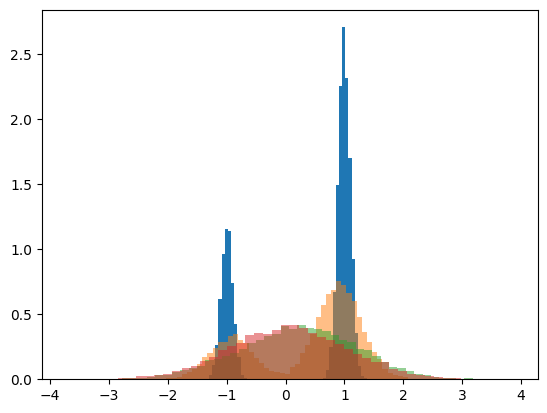

In [4]:
def forward_sample(a, t = None):
    x = -1 if random.random() < a else 1
    t = random.randint(1, T) if t is None else t
    z = random.normalvariate(0,1)
    x_t = np.sqrt(alpha_bar[t])*x + np.sqrt(1-alpha_bar[t])*z
    return x, x_t, t

def forward_batch(batch_size, a, t = None):
    x_batch= []
    xt_batch = []
    t_batch = []
    for _ in range(batch_size):
        x, x_t, t = forward_sample(a, t)
        x_batch += [x]
        xt_batch += [x_t]
        t_batch += [t]
    return x_batch, xt_batch, t_batch

a_demo = 0.3
N = 10000
_, x1, _ = forward_batch(N, a_demo, 1)
_, x5, _ = forward_batch(N, a_demo, 5)
_, x15, _ = forward_batch(N, a_demo, 15)
_, x25, _ = forward_batch(N, a_demo, 25)

plt.hist(x1, bins=50, density=True);
plt.hist(x5, bins=50, density=True, alpha=0.5);
plt.hist(x15, bins=50, density=True, alpha=0.5);
plt.hist(x25, bins=50, density=True, alpha=0.5);

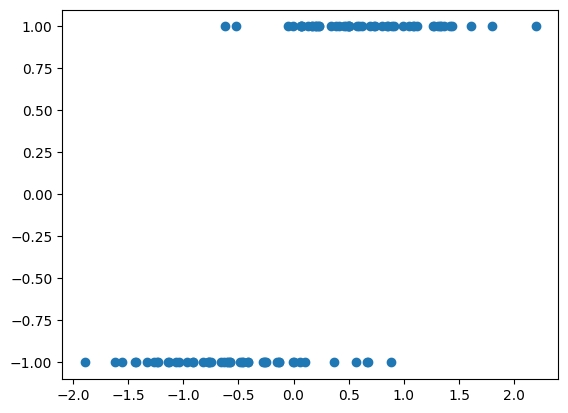

In [5]:
x, y, t = forward_batch(100, 0.5, 10)
plt.scatter(y,x)

In [6]:
t

[10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10,
 10]

In [7]:
n_iters = 5000
batch_size = 256
a = 0.3
X = []
Y = []
t_data = []

for _ in range(n_iters):
    x, x_t, t = forward_batch(batch_size, a, random.randint(1,T))
    X.append(np.array(x))
    Y.append(np.array(x_t))
    t_data.append(np.array(t))

X = iter(X)
Y = iter(Y)
t_data = iter(t_data)


Training with a = 0.1 ...
  iter     0: loss = 1.3141
  iter   100: loss = 0.1717
  iter   200: loss = 0.2065
  iter   300: loss = 0.2472
  iter   400: loss = 0.2524
  iter   500: loss = 0.1599
  iter   600: loss = 0.1808
  iter   700: loss = 0.2042
  iter   800: loss = 0.2474
  iter   900: loss = 0.2728
  iter  1000: loss = 0.2017
  iter  1100: loss = 0.1420
  iter  1200: loss = 0.3107
  iter  1300: loss = 0.1277
  iter  1400: loss = 0.2273
  iter  1500: loss = 0.1940
  iter  1600: loss = 0.2182
  iter  1700: loss = 0.2833
  iter  1800: loss = 0.2804
  iter  1900: loss = 0.1897
  iter  2000: loss = 0.2058
  iter  2100: loss = 0.2125
  iter  2200: loss = 0.2618
  iter  2300: loss = 0.1808
  iter  2400: loss = 0.1977
  iter  2500: loss = 0.2394
  iter  2600: loss = 0.1515
  iter  2700: loss = 0.1638
  iter  2800: loss = 0.2120
  iter  2900: loss = 0.2448
  iter  3000: loss = 0.1629
  iter  3100: loss = 0.2276
  iter  3200: loss = 0.2591
  iter  3300: loss = 0.2191
  iter  3400: loss = 0

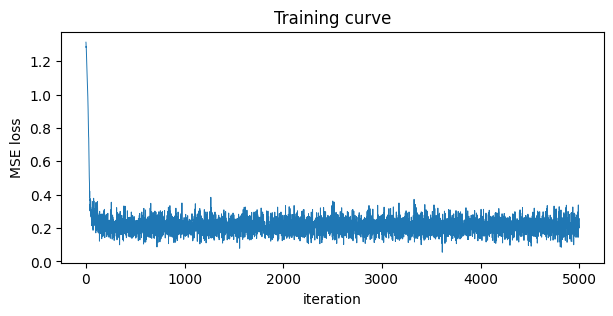

In [8]:
class DenoiserMLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
    )

    def forward(self, x_t, t):
        t = t / T
        input = torch.stack([x_t, t], dim=-1)
        return self.net(input).squeeze(-1)


def sample_batch(batch_size, a):
    """Sample (x_0, x_t, t) triples using the one-shot forward formula."""
    x_0 = torch.where(torch.rand(batch_size) < a, -1.0, 1.0)
    t = torch.randint(1, T + 1, (batch_size,))  # t in {1, ..., T}
    z = torch.randn(batch_size)
    abar = alpha_bar[t]
    x_t = torch.sqrt(abar) * x_0 + torch.sqrt(1 - abar) * z
    return x_0, x_t, t

def train(X,Y,t_data,a, n_iters=1000, batch_size=256, lr=1e-3, verbose=True):
    model = DenoiserMLP()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for i in range(n_iters):
        x,y,t = sample_batch(batch_size, a)
        x_pred = model(y,t)
        loss = ((x_pred - x)**2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if verbose and (i % 100 == 0 or i == n_iters - 1):
            print(f'  iter {i:>5d}: loss = {loss.item():.4f}')
    return model, losses


aa = 0.1
print(f"Training with a = {aa} ...")
model, losses = train(X,Y,t_data,a=aa, n_iters=5000)

plt.figure(figsize=(7, 3))
plt.plot(losses, lw=0.7)
plt.xlabel('iteration')
plt.ylabel('MSE loss')
plt.title('Training curve')
plt.show()

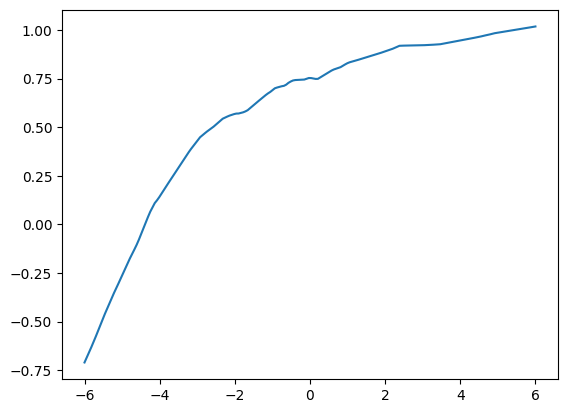

In [9]:
X = torch.linspace(-6,6,200)
t = torch.ones_like(X) * 25
with torch.no_grad():
    y = model(X,t)
plt.plot(X,y)

In [10]:
beta

tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900, 0.1000, 0.1100, 0.1200, 0.1300, 0.1400, 0.1500, 0.1600, 0.1700,
        0.1800, 0.1900, 0.2000, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500])

In [11]:
torch.cumsum(beta,0)

tensor([0.0000, 0.0100, 0.0300, 0.0600, 0.1000, 0.1500, 0.2100, 0.2800, 0.3600,
        0.4500, 0.5500, 0.6600, 0.7800, 0.9100, 1.0500, 1.2000, 1.3600, 1.5300,
        1.7100, 1.9000, 2.1000, 2.3100, 2.5300, 2.7600, 3.0000, 3.2500])